<a href="https://colab.research.google.com/github/IvanovaNadezda/product-analytics/blob/main/%D0%9F%D1%80%D0%BE%D0%B4%D1%83%D0%BA%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%BA%D0%B5%D0%B9%D1%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

file_path = 'Данные для кейса по ПА.xlsx'
df_users = pd.read_excel(file_path, sheet_name='Пользователи')
df_payments = pd.read_excel(file_path, sheet_name='Платежи')


# Предобработка данных
df_users = df_users.dropna(subset=['user_id', 'group', 'city'])

df_users = df_users[(df_users['age'] > 0) & (df_users['age'] < 100)]

df_payments = df_payments.dropna(subset=['user_id'])

# Рассчитываем воронку по пользователям, берем максимальное значение, т.к. попыток может быть несколько
df_user_payments = df_payments.groupby('user_id').agg({
    'step1_opened': lambda x: x.notnull().max(),
    'step4_success': lambda x: x.notnull().max()
}).reset_index()

df_user_payments.columns = ['user_id', 'has_step1', 'has_step4']

df_merged = df_user_payments.merge(df_users, on='user_id', how='inner')

df_active_users = df_merged[df_merged['has_step1'] == True]


summary = df_active_users.groupby('group').agg(
    total_users=('user_id', 'count'),
    success_users=('has_step4', 'sum')
).reset_index()

summary['conversion'] = summary['success_users'] / summary['total_users']

print("----- РЕЗУЛЬТАТЫ А/Б ТЕСТА -----")
print(summary.to_string(index=False))


count = summary['success_users'].values
nobs = summary['total_users'].values

stat, pval = proportions_ztest(count, nobs)
print("\n----- СТАТИСТИЧЕСКИЙ ТЕСТ -----")
print(f"Z-статистика: {stat:.4f}")
print(f"p-value: {pval:.5f}")
print("\n-------------------------------")
if pval < 0.05:
    print("Результат СТАТИСТИЧЕСКИ СИГНИФИКАНТЕН. Различия между группами реальны.")
else:
    print("Результат НЕ СИГНИФИКАНТЕН. Различия могут быть случайными.")


----- РЕЗУЛЬТАТЫ А/Б ТЕСТА -----
group  total_users  success_users  conversion
    A          750            493    0.657333
    B          750            603    0.804000

----- СТАТИСТИЧЕСКИЙ ТЕСТ -----
Z-статистика: -6.4024
p-value: 0.00000

-------------------------------
Результат СТАТИСТИЧЕСКИ СИГНИФИКАНТЕН. Различия между группами реальны.


/tmp/ipykernel_4785/534449423.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Группа A\n(Контроль)', 'Группа B\n(Новая форма)'], fontsize=11)


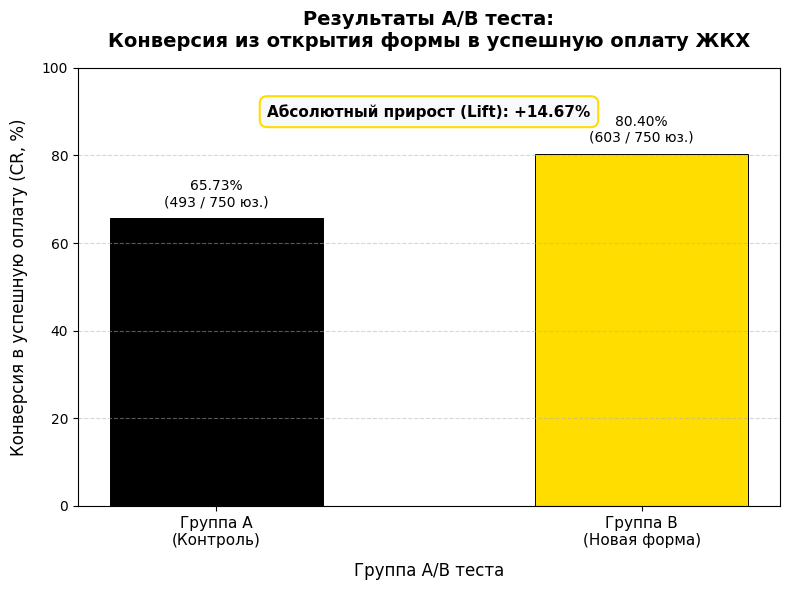

In [9]:
# Визуализация
groups = summary['group'].values
conversions = summary['conversion'].values * 100
totals = summary['total_users'].values
successes = summary['success_users'].values

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#000000', '#ffdd00']

bars = ax.bar(groups, conversions, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

ax.set_ylabel('Конверсия в успешную оплату (CR, %)', fontsize=12, labelpad=10)
ax.set_xlabel('Группа А/В теста', fontsize=12, labelpad=10)
ax.set_title('Результаты A/B теста:\nКонверсия из открытия формы в успешную оплату ЖКХ',
             fontsize=14, pad=15, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_xticklabels(['Группа A\n(Контроль)', 'Группа B\n(Новая форма)'], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, total, success, conv in zip(bars, totals, successes, conversions):
    height = bar.get_height()

    label_text = f'{conv:.2f}%\n({success} / {total} юз.)'

    ax.text(
        bar.get_x() + bar.get_width() / 2, # Координата X — центр столбца
        height + 2,                        # Координата Y — чуть выше вершины
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold' if bar.get_facecolor() == (46/255, 204/255, 113/255, 1.0) else 'normal'
    )

lift = conversions[1] - conversions[0]
ax.text(0.5, 90, f'Абсолютный прирост (Lift): +{lift:.2f}%',
        ha='center', va='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#ffdd00', lw=1.5))

plt.tight_layout()
plt.show()
